# Applied Economics Project: Statistical Data Analytics for Macroeconomic Indicators

**Based on:** Steinkamp, *Python for Engineering and Scientific Computing*, Chapter 9 — Statistical Computations

## Project Overview
In manufacturing, engineers monitor workpiece dimensions with statistical process control (SPC) so that
defects are caught *before* they happen. In this project you will apply the **same statistical toolkit**
(location parameters, dispersion parameters, frequency distributions, the normal distribution, skewness,
regression analysis, and control charts) to **macroeconomic data**:

| Manufacturing concept (book) | Economics analogue (this project) |
|---|---|
| Gear-shaft diameter measurements | Monthly inflation rate (%) |
| Workpiece sample (n = 5 per hour) | Regional unemployment sample (n = 5 regions per quarter) |
| Tolerance band on a technical drawing | Central bank inflation target band |
| Machine capability index Cm, Cmk | "Monetary policy capability" index |
| Roughness depth / resistance value | Monthly stock market returns |
| Relative humidity → fiber moisture (regression) | Inflation rate → unemployment rate (Phillips curve) |
| Quality control chart (SPC) | Regional unemployment control chart |

### Learning goals
1. Simulate realistic macroeconomic time series with NumPy.
2. Persist and reload data from disk (as a real statistical office would).
3. Compute and interpret location parameters (mean, median, mode, harmonic & geometric mean).
4. Compute and interpret dispersion parameters (span, standard deviation) and build a
   "policy capability index" analogous to Cm / Cmk.
5. Build frequency tables / histograms and connect them to the normal distribution.
6. Use `scipy.integrate.quad` (or `scipy.stats.norm`) to compute probabilities under the normal curve.
7. Compute skewness and interpret tail risk in financial returns.
8. Run a linear regression (Phillips curve) with `scipy.stats.linregress` and interpret r, m, a.
9. Build a two-lane control chart to monitor regional unemployment dispersion over time.

> Work through the notebook section by section. Each section has a short **theory recap**, followed by a
> code cell with `# TODO` markers for you to complete. Consult the accompanying **cheat sheet** if you
> get stuck.

## 0. Setup

Import the libraries you will need throughout the project. This mirrors Listing 9.1–9.17 of the book,
where `numpy`, `scipy.stats`, `scipy.integrate`, and `matplotlib.pyplot` form the core toolkit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.integrate import quad

np.random.seed(42)                 # reproducibility
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Generating Simulated Macroeconomic Data

Just as Listing 9.1 uses `np.random.normal(setpoint, s, size=n)` to simulate a gear-shaft diameter, we
simulate **60 months** of three indicators for a fictitious country "Economland":

* **Inflation rate** — normally distributed around a central-bank target of **3.0 %** with a standard
  deviation of **0.5 %**.
* **Stock market monthly return** — normally distributed around **0.8 %** with a standard deviation of
  **4.0 %** (returns can be negative).
* **Unemployment rate** — follows a simplified **Phillips-curve** relationship with inflation:
  `unemployment = 8 - 1.5 * inflation + noise`, where `noise ~ N(0, 0.6)`.

Round all values to 2 decimal places (as in Listing 9.1, `np.around(values, decimals=2)`).

In [2]:
n = 60  # months
inflation = np.random.normal(3.0, 0.5, size=n)
inflation = np.around(inflation, decimals=2)

stock_returns = np.random.normal(0.8, 4.0, size=n)
stock_returns = np.around(stock_returns, decimals=2)

noise = np.random.normal(0, 0.6, size=n)
unemployment = 8 - 1.5 * inflation + noise
unemployment = np.around(unemployment, decimals=2)

months = np.arange(1, n + 1)

df = pd.DataFrame({
    "month": months,
    "inflation": inflation,
    "unemployment": unemployment,
    "stock_return": stock_returns
})
print(df.head())
print("Type of inflation array:", type(inflation))


   month  inflation  unemployment  stock_return
0      1       3.25          3.60         -1.12
1      2       2.93          3.06          0.06
2      3       3.32          3.86         -3.63
3      4       3.76          1.52         -3.98
4      5       2.88          4.03          4.05
Type of inflation array: <class 'numpy.ndarray'>


## 2. Persisting and Reloading the Data

In real life, statistical offices store measurement series on disk. Listing 9.3 / 9.4 use
`np.savetxt()` and `np.loadtxt()`. Here, save the full DataFrame to a CSV file with `df.to_csv()`, then
reload it with `pd.read_csv()` and confirm the reloaded data matches the original.

In [3]:
df.to_csv("economland_data.csv", index=False)

df_loaded = pd.read_csv("economland_data.csv")
print("Number of rows loaded:", len(df_loaded))
print(df_loaded.head())

# sanity check
assert np.allclose(df["inflation"].values, df_loaded["inflation"].values)
print("Reloaded data matches original data.")


Number of rows loaded: 60
   month  inflation  unemployment  stock_return
0      1       3.25          3.60         -1.12
1      2       2.93          3.06          0.06
2      3       3.32          3.86         -3.63
3      4       3.76          1.52         -3.98
4      5       2.88          4.03          4.05
Reloaded data matches original data.


## 3. Frequency Distribution of the Inflation Rate

Following Section 9.2 of the book: determine the number of classes
$k = \lceil \sqrt{n} \rceil$, the span $R = x_{max}-x_{min}$, and the class interval $w = R/k$.
Then build a frequency table with `np.histogram()` and visualize it with `ax.hist()`.

Minimum inflation: 2.02
Maximum inflation: 3.93
Span: 1.91
Number of classes: 8
Class interval: 0.24
Absolute frequency: [ 4  8  8 13 12  7  4  4]
Relative frequency (%): [ 6.66666667 13.33333333 13.33333333 21.66666667 20.         11.66666667
  6.66666667  6.66666667]


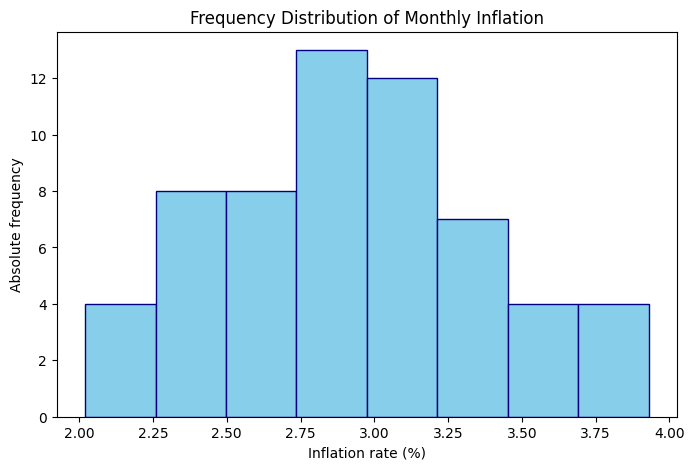

In [4]:
values = df_loaded["inflation"].values
n = len(values)
k = int(np.sqrt(n) + 0.5)
minimum = np.amin(values)
maximum = np.amax(values)
R = round(maximum - minimum, 2)
w = round(R / k, 2)

H, I = np.histogram(values, bins=k)
h = 100 * H / n

print("Minimum inflation:", minimum)
print("Maximum inflation:", maximum)
print("Span:", R)
print("Number of classes:", k)
print("Class interval:", w)
print("Absolute frequency:", H)
print("Relative frequency (%):", h)

fig, ax = plt.subplots()
ax.hist(values, bins=k, edgecolor="navy", color="skyblue")
ax.set(xlabel="Inflation rate (%)", ylabel="Absolute frequency",
       title="Frequency Distribution of Monthly Inflation")
plt.show()


## 4. Location Parameters of the Inflation Rate

Section 9.3 of the book covers four location parameters. Because inflation values here are all
positive, we can safely compute all four:

$$\bar{x}=\frac{1}{n}\sum_{i=1}^n x_i \qquad
\bar{x}_{harmonic} = n\left(\sum_{i=1}^n \frac{1}{x_i}\right)^{-1} \qquad
\bar{x}_{geometric} = \sqrt[n]{x_1 \cdot x_2 \cdots x_n}$$

Use `np.mean()`, `np.median()`, `scipy.stats.mode()`, `scipy.stats.hmean()`, and `scipy.stats.gmean()`.

In [5]:
mw = np.mean(values)
md_ = np.median(values)
mode_result = stats.mode(values, keepdims=True)
hm = stats.hmean(values)
gm = stats.gmean(values)

print("Mode:", mode_result)
print("Arithmetic mean:", mw)
print("Median:", md_)
print("Harmonic mean:", hm)
print("Geometric mean:", gm)


Mode: ModeResult(mode=array([2.77]), count=array([4]))
Arithmetic mean: 2.923
Median: 2.885
Harmonic mean: 2.8511493741075515
Geometric mean: 2.8874703752850697


## 5. Dispersion Parameters & a "Monetary-Policy Capability Index"

Section 9.4 of the book computes a *machine capability index* $C_m = T/(6s) \ge 1.67$ to check whether a
machine can reliably stay within a tolerance band. We build the economic analogue:

Suppose the central bank's official **inflation target band** is **[1.5 %, 4.5 %]** (tolerance
$T = 4.5-1.5 = 3.0$). Compute:

* the standard deviation $s$ of the inflation series (`np.std(values, ddof=1)`)
* the **capability index** $C_m = T / (6s)$ — analogous to machine capability: is monetary policy
  "capable" of consistently hitting the target band? ($C_m \ge 1.67$ is considered good.)
* the **centering index** $C_{mk} = \Delta_{krit} / (3s)$, where $\Delta_{krit}$ is the smaller of
  `(upper_limit - mean)` and `(mean - lower_limit)` — i.e., is the *average* inflation rate centered in
  the band, or is it drifting toward one edge?

In [6]:
s = np.std(values, ddof=1)
lower_limit, upper_limit = 1.5, 4.5
T = upper_limit - lower_limit
Cm = T / (6 * s)

delta_o = upper_limit - mw
delta_u = mw - lower_limit
delta_k = min(delta_o, delta_u)
Cmk = delta_k / (3 * s)

print("Standard deviation of inflation:", s)
print("Monetary policy capability index Cm:", Cm)
print("Monetary policy centering index Cmk:", Cmk)

if Cm >= 1.67 and Cmk >= 1.67:
    print("=> Monetary policy is well-controlled: inflation reliably stays within the target band.")
else:
    print("=> Monetary policy is NOT reliably capable of hitting the target band; investigate causes.")


Standard deviation of inflation: 0.4545152008421832
Monetary policy capability index Cm: 1.1000732188352265
Monetary policy centering index Cmk: 1.043602793601685
=> Monetary policy is NOT reliably capable of hitting the target band; investigate causes.


## 6. The Normal Distribution & Probability of Staying On-Target

Section 9.5 fits a Gaussian density $g(x)$ to the data and uses `scipy.integrate.quad` to compute the
probability that a value falls in a given range. Here we:

1. Plot the fitted normal density $g(x)$ for the inflation series (using the sample mean and std as
   $\mu$ and $\sigma$).
2. Compute the probability that inflation is **within the target band [1.5%, 4.5%]** by integrating the
   density over that range with `quad()`.
3. Compute (for comparison) the classic $\pm\sigma,\ \pm2\sigma,\ \pm3\sigma$ probabilities
   (68.27 %, 95.45 %, 99.73 %).

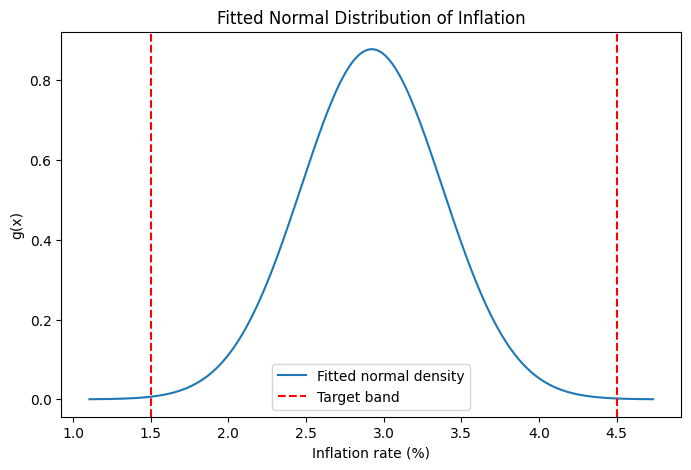

Probability inflation is within target band [1.5%, 4.5%]: 99.89%
Probability within ±1σ: 68.27%
Probability within ±2σ: 95.45%
Probability within ±3σ: 99.73%


In [7]:
def g(x, sigma, mu):
    return np.exp(-0.5 * (x - mu) ** 2 / sigma ** 2) / (sigma * np.sqrt(2 * np.pi))

mu, sigma = mw, s
x = np.arange(mu - 4 * sigma, mu + 4 * sigma, 0.01)
y = g(x, sigma, mu)

fig, ax = plt.subplots()
ax.plot(x, y, label="Fitted normal density")
ax.axvline(lower_limit, color="r", linestyle="--", label="Target band")
ax.axvline(upper_limit, color="r", linestyle="--")
ax.set(xlabel="Inflation rate (%)", ylabel="g(x)", title="Fitted Normal Distribution of Inflation")
ax.legend()
plt.show()

w_band, _ = quad(g, lower_limit, upper_limit, args=(sigma, mu))
w1, _ = quad(g, mu - sigma, mu + sigma, args=(sigma, mu))
w2, _ = quad(g, mu - 2 * sigma, mu + 2 * sigma, args=(sigma, mu))
w3, _ = quad(g, mu - 3 * sigma, mu + 3 * sigma, args=(sigma, mu))

print("Probability inflation is within target band [1.5%%, 4.5%%]: %.2f%%" % (100 * w_band))
print("Probability within ±1σ: %.2f%%" % (100 * w1))
print("Probability within ±2σ: %.2f%%" % (100 * w2))
print("Probability within ±3σ: %.2f%%" % (100 * w3))


## 7. Skewness of Stock Market Returns

Section 9.6 introduces skewness as a measure of asymmetry. Financial returns are often **negatively
skewed** (large crashes are more extreme than large rallies). Compute:

* Pearson's approximate skew: $S_1 = (\bar{x}-\tilde{x})/s$
* The exact skew via `scipy.stats.skew()`

and interpret the sign in terms of **tail risk**.

In [8]:
returns = df_loaded["stock_return"].values
mw_r = np.mean(returns)
md_r = np.median(returns)
s_r = np.std(returns, ddof=1)

S1 = (mw_r - md_r) / s_r
S2 = stats.skew(returns)

print("Mean return:", mw_r)
print("Median return:", md_r)
print("Std dev of returns:", s_r)
print("Skew (Pearson approximation):", S1)
print("Skew (exact, scipy):", S2)

if S2 < 0:
    print("=> Returns are right-skewed: infrequent but large negative shocks (crash risk).")
else:
    print("=> Returns are left-skewed: infrequent but large positive shocks.")


Mean return: 0.7849999999999998
Median return: 0.675
Std dev of returns: 3.77290676054005
Skew (Pearson approximation): 0.02915523944309042
Skew (exact, scipy): -0.09020542411155923
=> Returns are right-skewed: infrequent but large negative shocks (crash risk).


## 8. Regression Analysis: The Phillips Curve

Section 9.7 regresses moisture content on humidity. Here we regress **unemployment (Y)** on
**inflation (X)** — the textbook Phillips-curve trade-off. Use `scipy.stats.linregress()` to obtain the
slope $m$, intercept $a$, and correlation coefficient $r$, then plot the scatter plot with the fitted
regression line.

Slope (m): -1.3540061664886305
Intercept (a): 7.6285933579796
Correlation coefficient (r): -0.7197653588979114
Regression equation: unemployment = -1.354 * inflation + 7.629


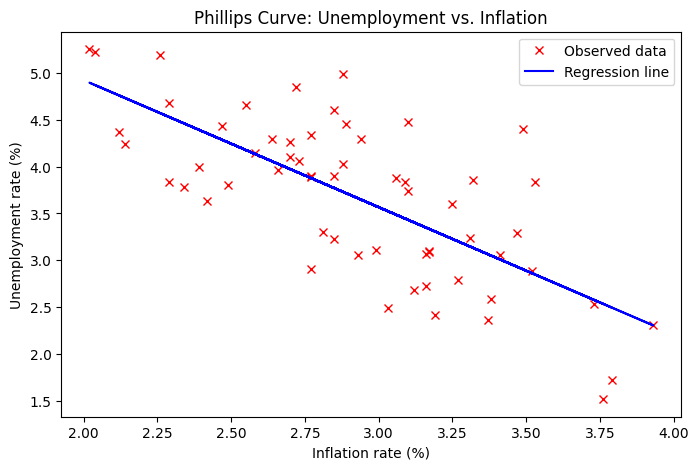

=> Strong negative correlation: supports a Phillips-curve trade-off in this sample.


In [9]:
X = df_loaded["inflation"].values
Y = df_loaded["unemployment"].values

m, a, r, p, e = stats.linregress(X, Y)

print("Slope (m):", m)
print("Intercept (a):", a)
print("Correlation coefficient (r):", r)
print("Regression equation: unemployment = %.3f * inflation + %.3f" % (m, a))

fig, ax = plt.subplots()
ax.plot(X, Y, "rx", label="Observed data")
ax.plot(X, m * X + a, "b-", label="Regression line")
ax.set_xlabel("Inflation rate (%)")
ax.set_ylabel("Unemployment rate (%)")
ax.set_title("Phillips Curve: Unemployment vs. Inflation")
ax.legend()
plt.show()

if r < -0.5:
    print("=> Strong negative correlation: supports a Phillips-curve trade-off in this sample.")
elif r > 0.5:
    print("=> Strong positive correlation (unusual — check data / consider stagflation).")
else:
    print("=> Weak correlation: little evidence of a Phillips-curve trade-off in this sample.")


## 9. Project Task: A Regional Unemployment Control Chart

Mirroring Section 9.8, imagine the national statistics office samples the unemployment rate in
**5 regions every quarter** for **10 quarters** and wants a two-lane control chart (mean chart +
standard-deviation chart) to spot regions/quarters where dispersion across regions becomes abnormal
(a signal of diverging regional economies needing policy attention).

Use factors for a sample size of n = 5 (same as the book): $A_3 = 1.152$, $B_4 = 1.669$.

$$UCL_{\bar x} = \bar{\bar x} + A_3 \bar s \qquad LCL_{\bar x} = \bar{\bar x} - A_3 \bar s \qquad
UCL_s = B_4 \bar s$$

Table of regional unemployment rates (rows=regions, cols=quarters):
 [[6.56 6.64 5.6  6.35 6.32 5.16 6.51 6.68 8.08 6.98]
 [5.23 6.43 6.77 5.2  6.5  6.46 7.02 5.3  4.32 6.06]
 [5.04 5.93 6.19 6.14 6.97 6.46 6.86 5.79 6.62 5.03]
 [6.43 5.24 4.88 6.05 6.95 6.46 6.59 5.56 4.55 5.36]
 [5.8  4.64 6.16 4.97 4.76 9.47 5.72 6.07 5.58 6.61]]
Quarterly mean unemployment: [np.float64(5.81), np.float64(5.78), np.float64(5.92), np.float64(5.74), np.float64(6.3), np.float64(6.8), np.float64(6.54), np.float64(5.88), np.float64(5.83), np.float64(6.01)]
Quarterly std dev: [np.float64(0.685), np.float64(0.833), np.float64(0.714), np.float64(0.615), np.float64(0.906), np.float64(1.594), np.float64(0.502), np.float64(0.53), np.float64(1.555), np.float64(0.819)]
Mean chart UCL / LCL: 7.069345599999999 5.052654399999999
Std-dev chart UCL: 1.4608756999999999


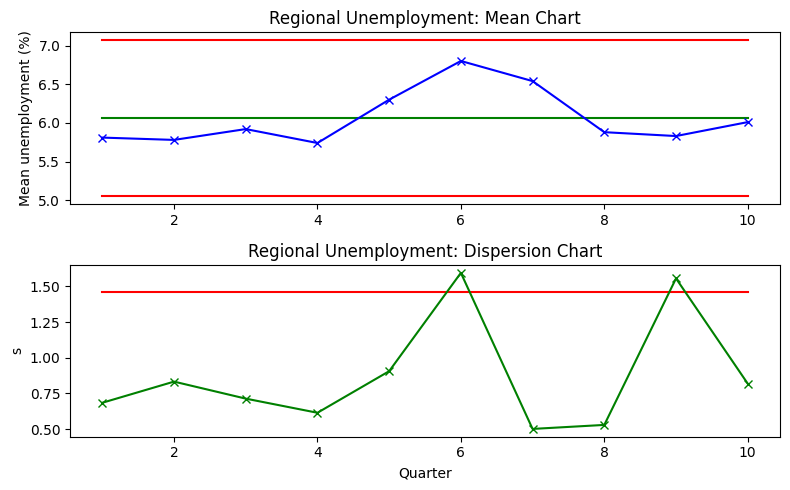

Quarters where the mean chart signals a policy-relevant deviation: []


In [10]:
rows, columns = 5, 10          # 5 regions, 10 quarters
A3, B4 = 1.152, 1.669

# simulate regional unemployment: national trend +/- regional deviation
national_target = 6.0
regional_data = np.random.normal(national_target, 0.9, size=rows * columns)
regional_data = np.around(regional_data, decimals=2)
table = np.reshape(regional_data, (rows, columns), order="F")

quarter = np.arange(1, columns + 1)
mw_q, staw_q = [], []
for i in range(columns):
    mw_q.append(round(np.mean(table[0:rows, i]), 2))
    staw_q.append(round(np.std(table[0:rows, i], ddof=1), 3))

mmw = np.mean(mw_q)
mws = np.mean(staw_q)
UCLm = mmw + A3 * mws
LCLm = mmw - A3 * mws
UCLs = B4 * mws

print("Table of regional unemployment rates (rows=regions, cols=quarters):\n", table)
print("Quarterly mean unemployment:", mw_q)
print("Quarterly std dev:", staw_q)
print("Mean chart UCL / LCL:", UCLm, LCLm)
print("Std-dev chart UCL:", UCLs)

x = [1, columns]
fig, ax = plt.subplots(2, 1)
ax[0].set_title("Regional Unemployment: Mean Chart")
ax[0].plot(x, [UCLm, UCLm], "r-")
ax[0].plot(x, [mmw, mmw], "g-")
ax[0].plot(x, [LCLm, LCLm], "r-")
ax[0].plot(quarter, mw_q, "bx-")
ax[0].set_ylabel("Mean unemployment (%)")

ax[1].set_title("Regional Unemployment: Dispersion Chart")
ax[1].plot(x, [UCLs, UCLs], "r-")
ax[1].plot(quarter, staw_q, "gx-")
ax[1].set_xlabel("Quarter")
ax[1].set_ylabel("s")

fig.tight_layout()
plt.show()

out_of_control = [q for q, mval in zip(quarter, mw_q) if mval > UCLm or mval < LCLm]
print("Quarters where the mean chart signals a policy-relevant deviation:", out_of_control)


## 10. Conclusions & Reflection

Answer the following in a markdown cell:

1. Based on Section 5's capability indices, is Economland's central bank reliably hitting its inflation
   target? Explain using $C_m$ and $C_{mk}$.
2. Based on Section 6, what is the probability that inflation stays inside the target band in any given
   month? Is this an acceptable risk for policymakers?
3. Based on Section 7, does the stock market in this simulation show crash risk (negative skew) or rally
   risk (positive skew)?
4. Based on Section 8, do these data support a Phillips-curve trade-off? What is the economic
   interpretation of the slope $m$?
5. Based on Section 9, were there any quarters where regional unemployment dispersion signaled a
   need for policy intervention?

*(This is a synthetic dataset for practicing the statistical toolkit — repeat the analysis with real
data, e.g., from FRED, Eurostat, or the World Bank, as a stretch goal.)*

*(Write your answers here.)*